In [ ]:
import os
if os.path.basename(os.getcwd()) != 'nuclei-segmentation':
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")

# 🔬 Μέρος Β1 — Simple CNN Segmentation
Data Science Bowl 2018 — Nuclei Segmentation

## 0. Imports & Config

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as T
import torchvision.transforms.functional as TF
import random

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}')

# Paths
TRAIN_DIR   = Path('./data/raw/train')
WEIGHTS_DIR = Path('./outputs/model_weights')
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR = Path('./outputs/b1_cnn')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
IMG_SIZE   = 256
BATCH_SIZE = 8
N_EPOCHS   = 30
LR         = 1e-3
VAL_SPLIT  = 0.2
SEED       = 42

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f'Image size:  {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size:  {BATCH_SIZE}')
print(f'Epochs:      {N_EPOCHS}')
print(f'LR:          {LR}')

Device: mps
Image size:  256x256
Batch size:  8
Epochs:      30
LR:          0.001


## 1. Dataset & DataLoader

Train: 536 | Val: 134


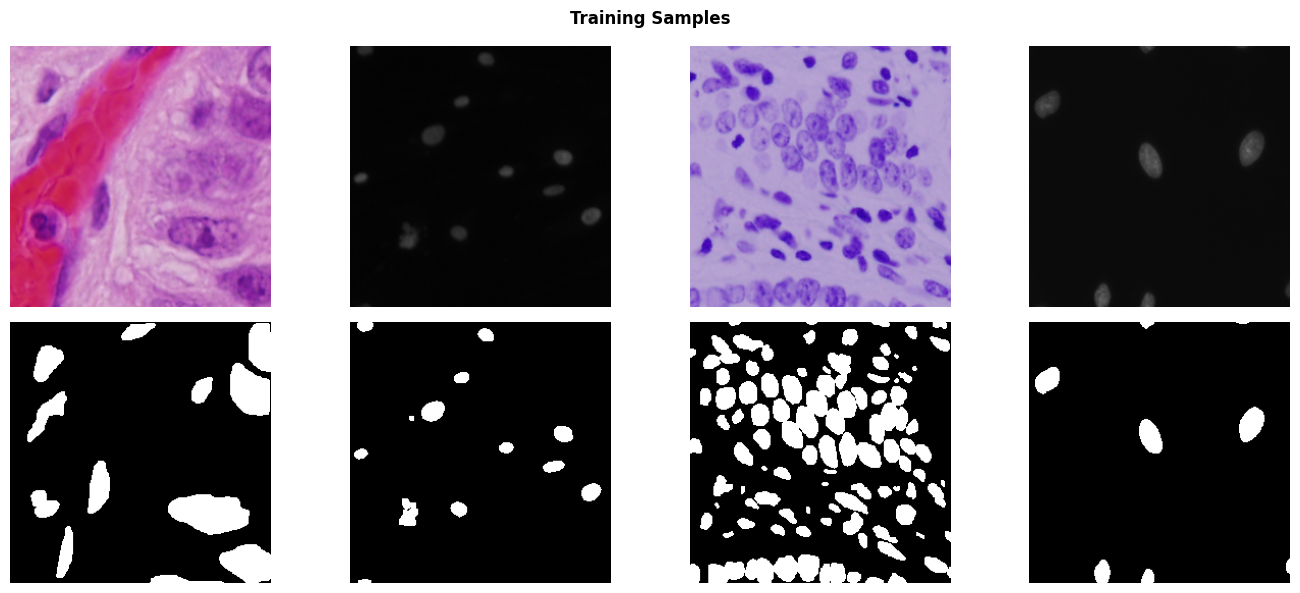

In [2]:
class NucleiDataset(Dataset):
    def __init__(self, train_dir, img_size=256, augment=False):
        self.train_dir = Path(train_dir)
        self.img_size  = img_size
        self.augment   = augment
        self.image_ids = sorted([x for x in os.listdir(train_dir) if not x.startswith('.')])

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id   = self.image_ids[idx]
        img_path = self.train_dir / img_id / 'images' / f'{img_id}.png'

        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)

        # Merge all masks
        mask_dir = self.train_dir / img_id / 'masks'
        combined = np.zeros((self.img_size, self.img_size), dtype=np.uint8)
        for mf in mask_dir.glob('*.png'):
            m = np.array(Image.open(mf).convert('L').resize((self.img_size, self.img_size), Image.NEAREST))
            combined = np.maximum(combined, (m > 0).astype(np.uint8))

        mask = Image.fromarray(combined * 255)

        if self.augment:
            if random.random() > 0.5:
                img, mask = TF.hflip(img), TF.hflip(mask)
            if random.random() > 0.5:
                img, mask = TF.vflip(img), TF.vflip(mask)
            angle = random.choice([0, 90, 180, 270])
            img = TF.rotate(img, angle)
            mask = TF.rotate(mask, angle)

        img_t  = T.ToTensor()(img)                    # [3, H, W]
        mask_t = T.ToTensor()(mask).squeeze(0)        # [H, W]
        mask_t = (mask_t > 0.5).float()

        return img_t, mask_t


# Split indices
full_dataset = NucleiDataset(TRAIN_DIR, img_size=IMG_SIZE, augment=False)
n_val = int(len(full_dataset) * VAL_SPLIT)
n_train = len(full_dataset) - n_val

train_idx, val_idx = random_split(
    range(len(full_dataset)), [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataset = Subset(NucleiDataset(TRAIN_DIR, IMG_SIZE, augment=True),  train_idx.indices)
val_dataset   = Subset(NucleiDataset(TRAIN_DIR, IMG_SIZE, augment=False), val_idx.indices)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)}')

# Visualize
imgs, masks = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i in range(min(4, len(imgs))):
    axes[0,i].imshow(imgs[i].permute(1,2,0).numpy())
    axes[0,i].axis('off')
    axes[1,i].imshow(masks[i].numpy(), cmap='gray')
    axes[1,i].axis('off')
plt.suptitle('Training Samples', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cnn_training_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Simple CNN Architecture

In [3]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class SimpleCNN(nn.Module):
    def __init__(self, in_channels=3, base_dim=32):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_dim)
        self.enc2 = ConvBlock(base_dim, base_dim*2)
        self.enc3 = ConvBlock(base_dim*2, base_dim*4)
        self.pool = nn.MaxPool2d(2, 2)

        self.bottleneck = ConvBlock(base_dim*4, base_dim*8)

        self.up3 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec3 = ConvBlock(base_dim*8, base_dim*4)

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2 = ConvBlock(base_dim*4, base_dim*2)

        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec1 = ConvBlock(base_dim*2, base_dim)

        self.out = nn.Conv2d(base_dim, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.dec3(self.up3(b))
        d2 = self.dec2(self.up2(d3))
        d1 = self.dec1(self.up1(d2))

        return self.out(d1)


model = SimpleCNN(in_channels=3, base_dim=32).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SimpleCNN parameters: {n_params:,} ({n_params/1e6:.2f}M)')

dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
print('Output shape:', model(dummy).shape)

SimpleCNN parameters: 1,754,753 (1.75M)
Output shape: torch.Size([2, 1, 256, 256])


## 3. Loss Function

In [4]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).view(-1)
        tgts  = targets.view(-1)
        intersection = (probs * tgts).sum()
        return 1 - (2 * intersection + self.smooth) / (probs.sum() + tgts.sum() + self.smooth)


class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + 0.5 * self.dice(logits, targets)


criterion = CombinedLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)
print('Loss & optimizer ready.')

Loss & optimizer ready.


## 4. Metrics + Training Loop + Evaluation

In [5]:
def compute_metrics(preds, targets, threshold=0.5):
    probs = torch.sigmoid(preds).squeeze(1)
    binary = (probs > threshold).float()
    tgts = targets.float()

    p = binary.view(-1)
    t = tgts.view(-1)

    TP = (p * t).sum()
    FP = (p * (1 - t)).sum()
    FN = ((1 - p) * t).sum()
    TN = ((1 - p) * (1 - t)).sum()

    smooth = 1e-6
    iou = (TP + smooth) / (TP + FP + FN + smooth)
    dice = (2 * TP + smooth) / (2 * TP + FP + FN + smooth)
    pixel_acc = (TP + TN) / (TP + TN + FP + FN + smooth)
    precision = (TP + smooth) / (TP + FP + smooth)
    recall = (TP + smooth) / (TP + FN + smooth)

    return {
        'iou': iou.item(), 'dice': dice.item(), 'pixel_acc': pixel_acc.item(),
        'precision': precision.item(), 'recall': recall.item()
    }


# Training
history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_dice': []}
best_val_loss = float('inf')

for epoch in range(N_EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits.squeeze(1), masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0.0
    metrics_list = []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            loss = criterion(logits.squeeze(1), masks)
            val_loss += loss.item()
            metrics_list.append(compute_metrics(logits, masks))

    val_loss /= len(val_loader)
    val_iou = np.mean([m['iou'] for m in metrics_list])
    val_dice = np.mean([m['dice'] for m in metrics_list])

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(val_iou)
    history['val_dice'].append(val_dice)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), WEIGHTS_DIR / 'cnn_best.pth')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:2d}/{N_EPOCHS} | Train {train_loss:.4f} | Val {val_loss:.4f} | IoU {val_iou:.4f} | Dice {val_dice:.4f}')

torch.save(model.state_dict(), WEIGHTS_DIR / 'cnn_final.pth')
print(f'\nTraining finished. Best val loss: {best_val_loss:.4f}')

Epoch  5/30 | Train 0.2312 | Val 0.2538 | IoU 0.6248 | Dice 0.7679
Epoch 10/30 | Train 0.1907 | Val 0.1863 | IoU 0.6791 | Dice 0.8078
Epoch 15/30 | Train 0.1816 | Val 0.1941 | IoU 0.6648 | Dice 0.7974
Epoch 20/30 | Train 0.1610 | Val 0.1674 | IoU 0.7050 | Dice 0.8258
Epoch 25/30 | Train 0.1556 | Val 0.1507 | IoU 0.7321 | Dice 0.8446
Epoch 30/30 | Train 0.1485 | Val 0.1477 | IoU 0.7353 | Dice 0.8467

Training finished. Best val loss: 0.1477


### Training Curves

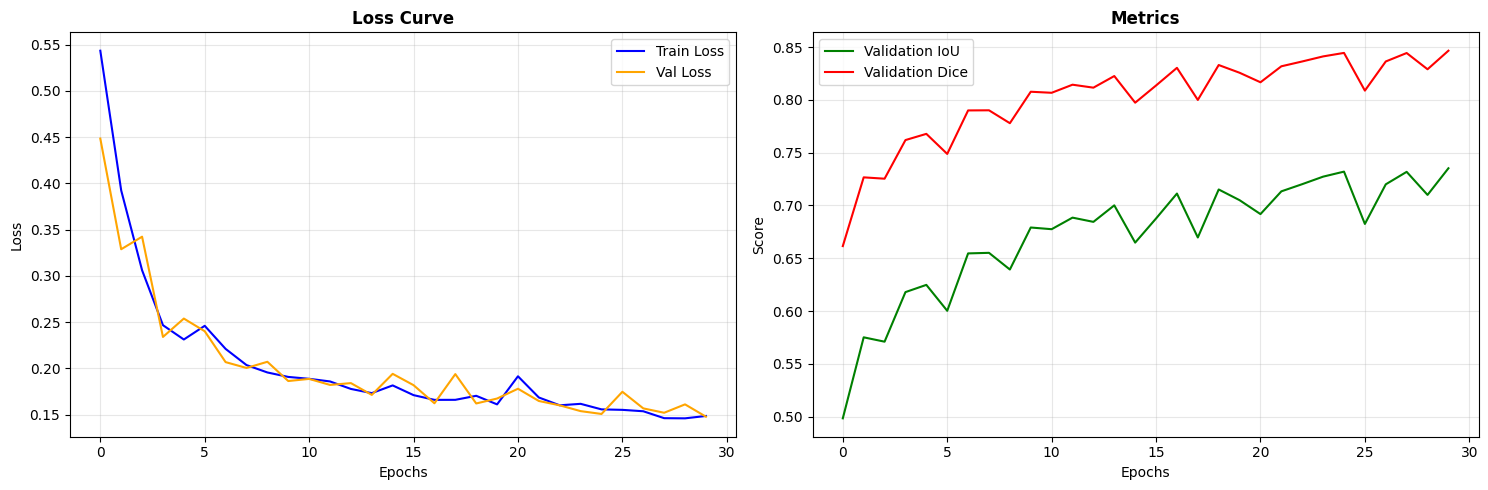

In [6]:
# Plot Training & Validation Loss
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Loss Curve', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['val_iou'], label='Validation IoU', color='green')
plt.plot(history['val_dice'], label='Validation Dice', color='red')
plt.title('Metrics', fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=120)
plt.show()

### Visual Evaluation (Predictions vs Truth)

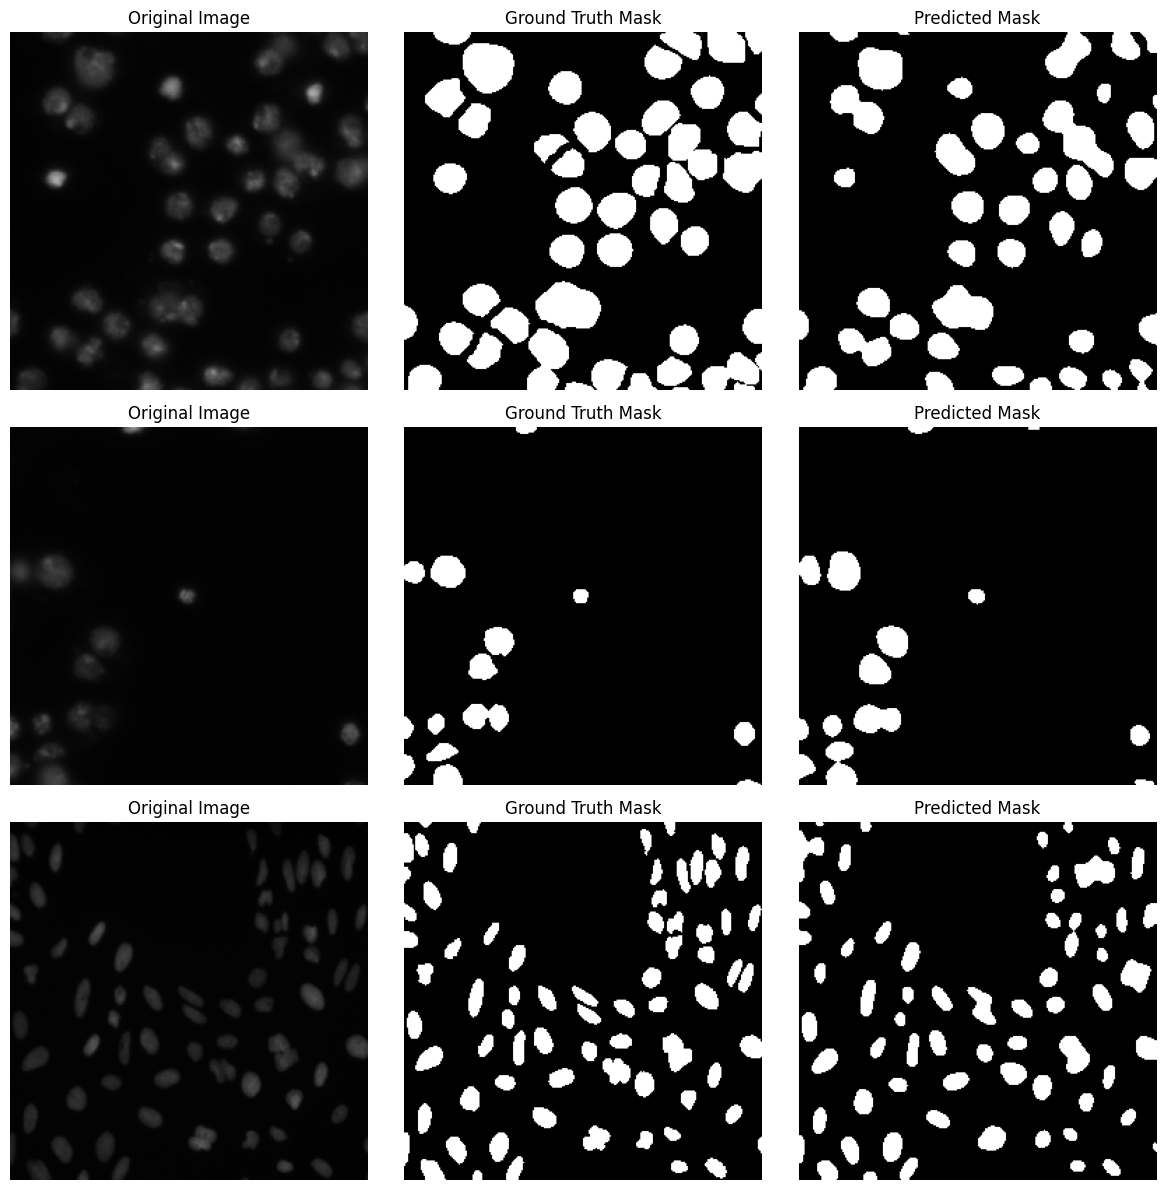

In [7]:
model.eval()
imgs, masks = next(iter(val_loader))
imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

with torch.no_grad():
    preds = model(imgs)
    # Handle tuple outputs (just in case)
    if isinstance(preds, tuple):
        preds = preds[0]
    probs = torch.sigmoid(preds).squeeze(1)
    preds_binary = (probs > 0.5).cpu().numpy()

imgs_np = imgs.cpu().permute(0, 2, 3, 1).numpy()
masks_np = masks.cpu().numpy()

# Plot 3 random validation samples
num_samples = min(3, len(imgs))
fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

for i in range(num_samples):
    # Original Image
    axes[i, 0].imshow(imgs_np[i])
    axes[i, 0].set_title('Original Image')
    axes[i, 0].axis('off')
    
    # Ground Truth Mask
    axes[i, 1].imshow(masks_np[i], cmap='gray')
    axes[i, 1].set_title('Ground Truth Mask')
    axes[i, 1].axis('off')
    
    # Predicted Mask
    axes[i, 2].imshow(preds_binary[i], cmap='gray')
    axes[i, 2].set_title('Predicted Mask')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'validation_predictions.png', dpi=120)
plt.show()